В данной работе проводится сравнения результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель с несколькими компонентами кинематического упрочнения - **CHAB**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [1]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress

real_experiment_data_folder = "."
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col="S_TT",
            s_y_col="S_ZZ",
            s_xy_col="S_TZ",
            new_col_name="S_EQV"
        )

### Методика проведения численного эксперимента

Расчет в **ANSYS** выполнялся в деформационном нагружении **поточечно**. Процесс моделирования был организован следующим образом:

*   **Синхронизация по шагам:** На каждом расчетном шаге (step) производилось прямое сопоставление с временной шкалой реального эксперимента.
*   **Граничные условия:** В качестве входных параметров численной модели на каждом шаге использовались компоненты тензора деформаций, полученные непосредственно из экспериментальных данных.
*   **Итерационный расчет:** Программа вычисляла отклик системы (напряжения) для каждой конкретной точки деформационного пути, что позволило обеспечить максимально точное соответствие условий нагружения в модели и в реальности.

*   **Два варианта материала в ANSYS:** сжимаемый и **несжимаемый** (`chab.csv` и `chab_incompressible.csv`); на графиках — две расчётные кривые и эксперимент.


In [2]:
from core.reader import read_ansys_csv

numerical_experiment_chab = read_ansys_csv("chab.csv")
numerical_experiment_chab_inc = read_ansys_csv("chab_incompressible.csv")



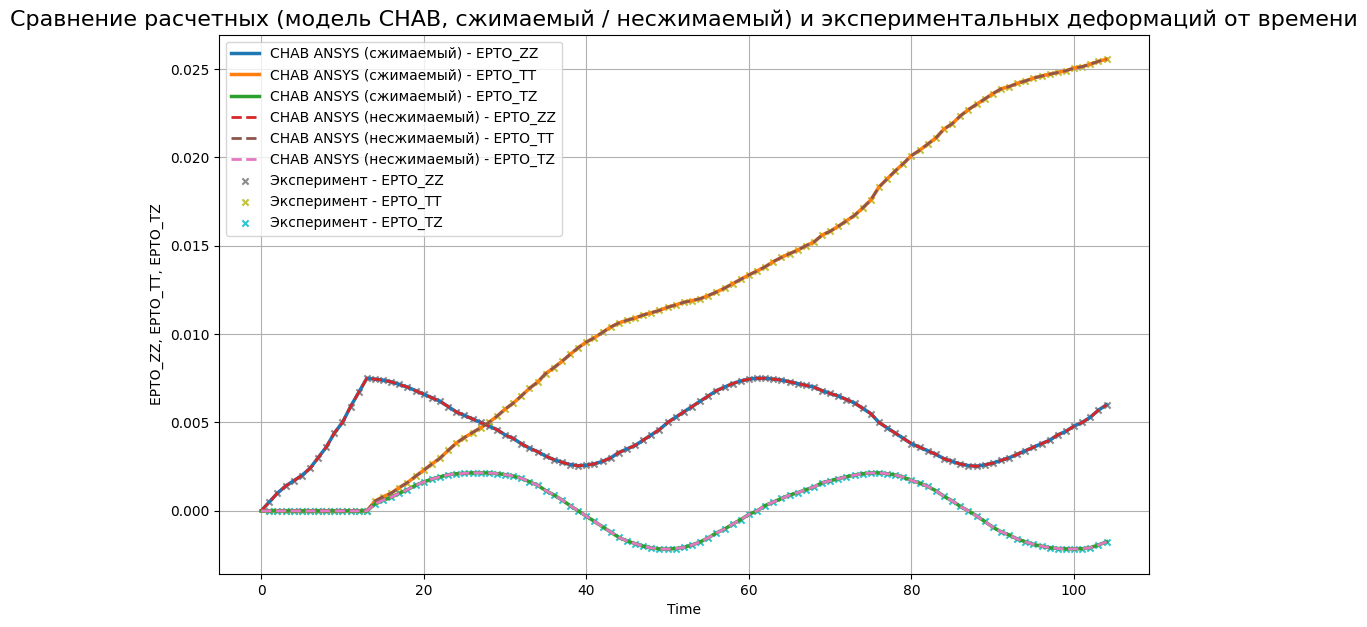

In [3]:
from core.visualizer import plot_xy

model_name = "CHAB"
_ansys_pairs = [
    (f"{model_name} ANSYS (сжимаемый)", numerical_experiment_chab),
    (f"{model_name} ANSYS (несжимаемый)", numerical_experiment_chab_inc),
]
plot_xy(
    _ansys_pairs,
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"Сравнение расчетных (модель {model_name}, сжимаемый / несжимаемый) и экспериментальных деформаций от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7),
)



Построим графики изменения компонент тензора напряжений и интенсивности напряжений от времени.

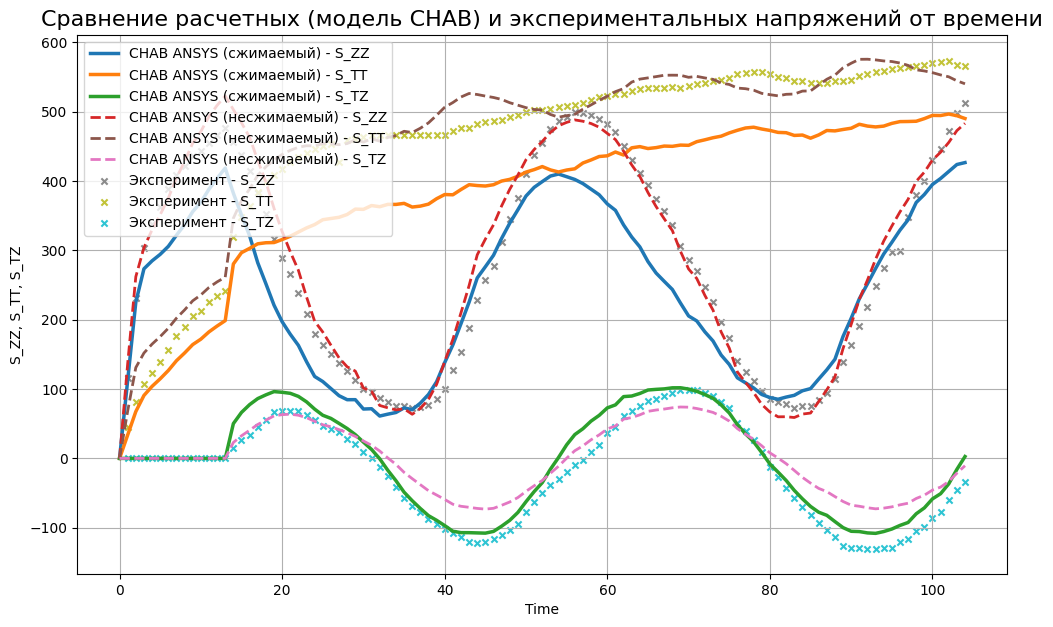

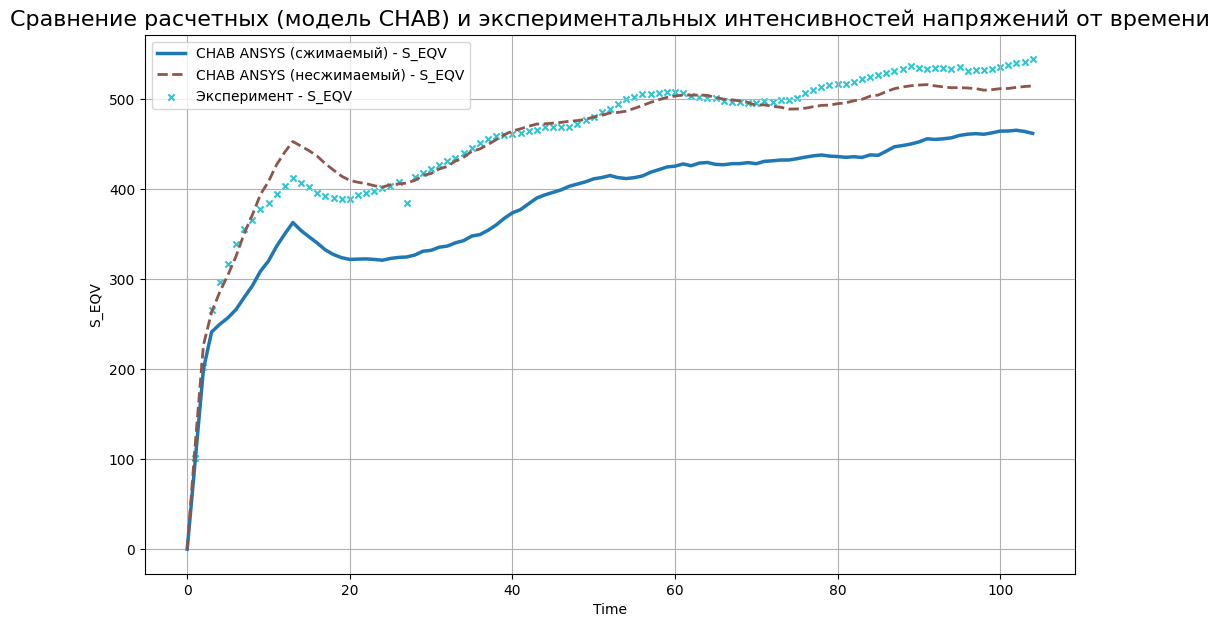

In [4]:
plot_xy(
    _ansys_pairs,
    "Time",
    ["S_ZZ", "S_TT", "S_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7),
)

plot_xy(
    _ansys_pairs,
    "Time",
    ["S_EQV"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7),
)



In [5]:
from core.calculations import prepare_ilushin_path_dataset

exp_il = prepare_ilushin_path_dataset(real_experiment, use_deviatoric_strains=False)
num_il = prepare_ilushin_path_dataset(numerical_experiment_chab, use_deviatoric_strains=True)
num_il_inc = prepare_ilushin_path_dataset(numerical_experiment_chab_inc, use_deviatoric_strains=True)

il_pairs = [
    (f"{model_name} (сжимаемый)", num_il),
    (f"{model_name} (несжимаемый)", num_il_inc),
]



**Компоненты вектора деформаций Ильюшина по времени.** Ниже для модели CHAB на одном графике для каждой компоненты `Eps_1`, `Eps_2`, `Eps_3` сравниваются:

- **расчётные кривые** — два варианта постановки (сжимаемый и несжимаемый материал);
- **эксперимент** — те же компоненты, полученные из опыта.

Абсцисса — **время** $t$ (`Time`), здесь проверяется согласование **по времени** между опытом и расчётом.

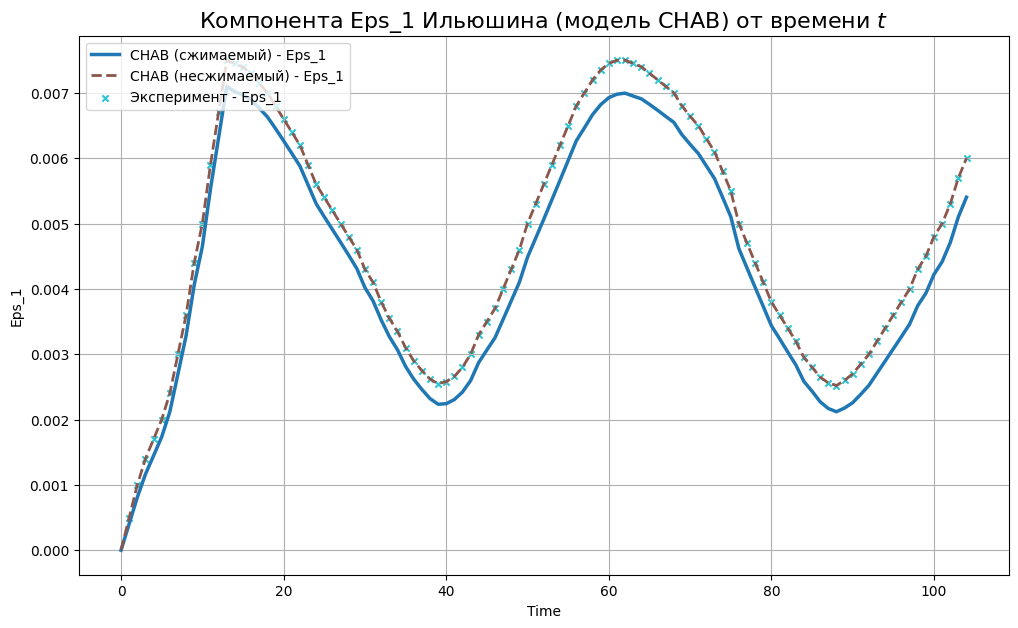

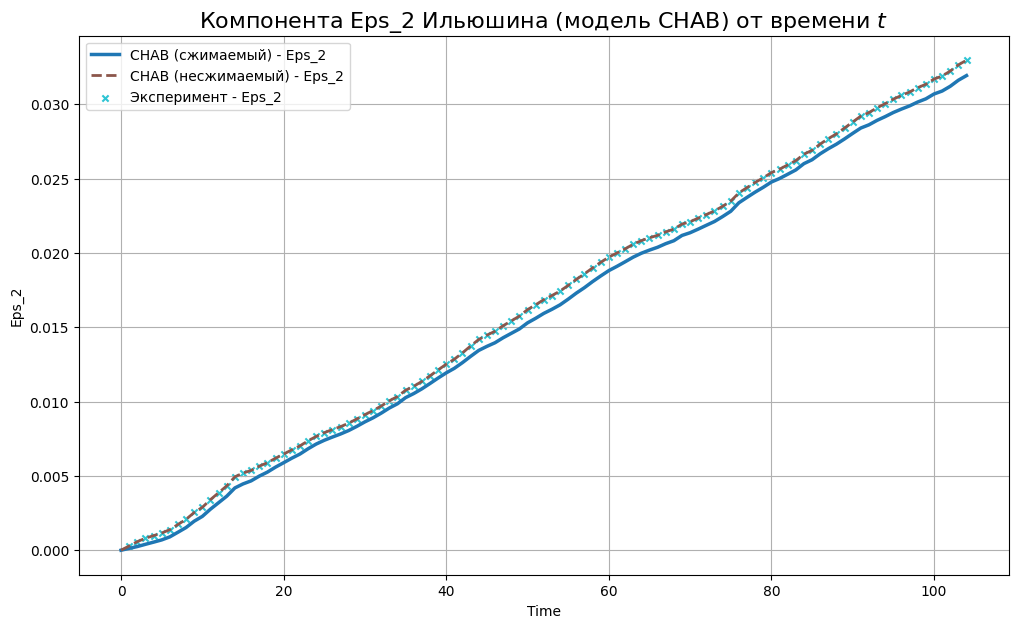

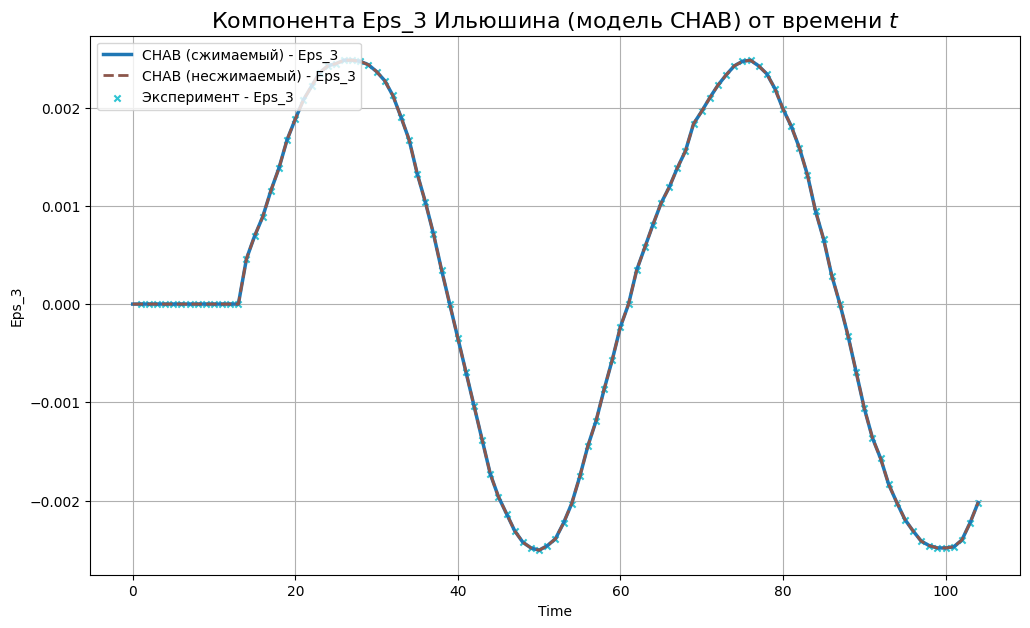

In [6]:
plot_xy(
    il_pairs,
    "Time",
    ["Eps_1"],
    f"Компонента Eps_1 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    il_pairs,
    "Time",
    ["Eps_2"],
    f"Компонента Eps_2 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    il_pairs,
    "Time",
    ["Eps_3"],
    f"Компонента Eps_3 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)



**Компоненты вектора напряжений Ильюшина по времени.**

Для каждой компоненты $\mathrm{Sig}_i$ (`Sig_1`, `Sig_2`, `Sig_3`) строятся графики от **времени** `Time`:

- **линии расчёта** — два варианта CHAB (сжимаемый и несжимаемый материал);
- **эксперимент** — рассчитанным из опытных напряжений той же процедурой.

Проверяем согласование **истории напряжений по времени** между опытом и расчётом.

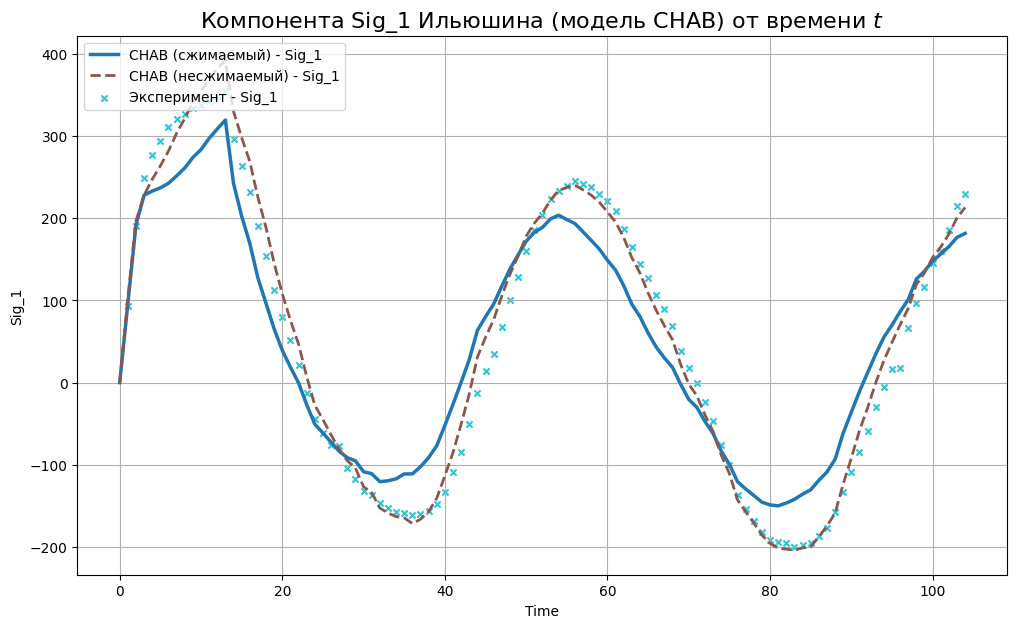

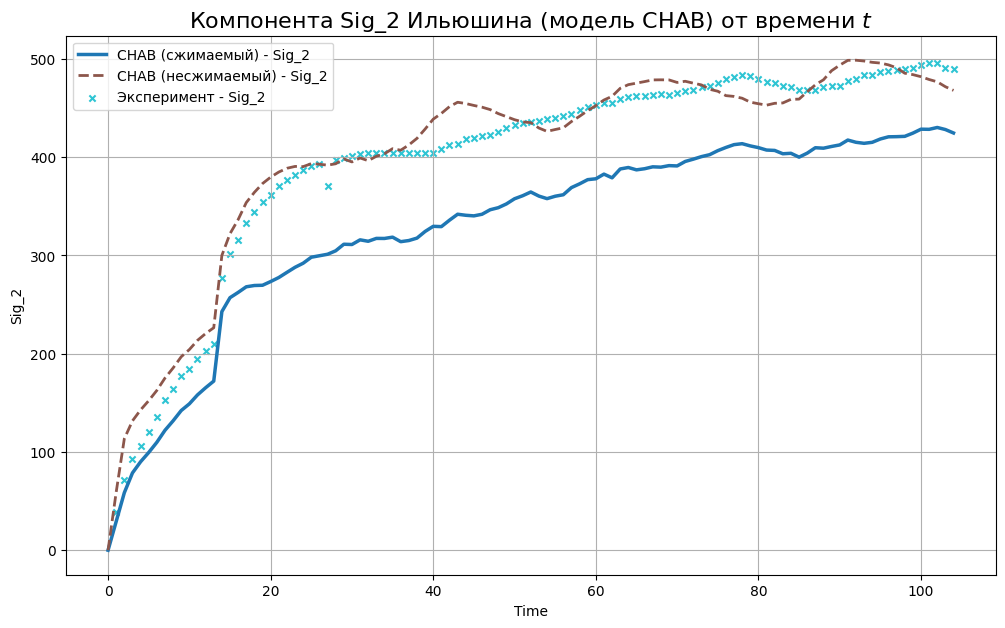

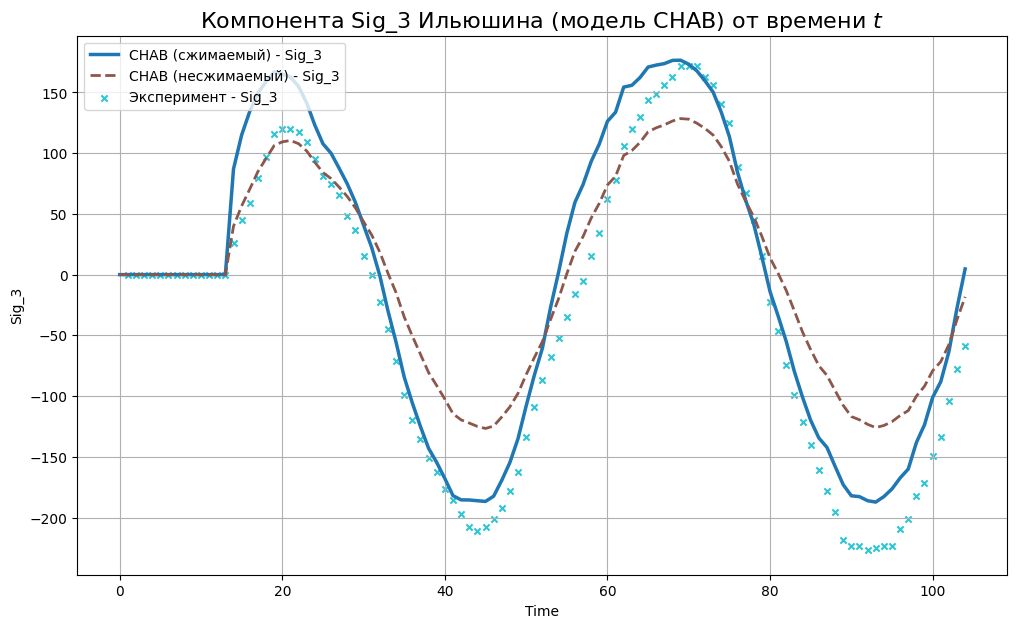

In [7]:
plot_xy(
    il_pairs,
    "Time",
    ["Sig_1"],
    f"Компонента Sig_1 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    il_pairs,
    "Time",
    ["Sig_2"],
    f"Компонента Sig_2 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    il_pairs,
    "Time",
    ["Sig_3"],
    f"Компонента Sig_3 Ильюшина (модель {model_name}) от времени $t$",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)




#### Угол между векторами напряжений Ильюшина ($\varphi$)
$$\varphi = \arccos\left(\frac{\vec{\sigma}^{\mathrm{числ}} \cdot \vec{\sigma}^{\mathrm{эксп}}}{|\vec{\sigma}^{\mathrm{числ}}| \cdot |\vec{\sigma}^{\mathrm{эксп}}|}\right).$$

#### Относительная разность модулей
$$\frac{|\vec{\sigma}^{\mathrm{числ}}| - |\vec{\sigma}^{\mathrm{эксп}}|}{|\vec{\sigma}^{\mathrm{эксп}}|}.$$

In [8]:
from core.calculations import ilushin_stress_metrics_at_experiment

df_metrics = ilushin_stress_metrics_at_experiment(
    real_experiment,
    numerical_experiment_chab,
    time_col="Time",
    direction="nearest",
)
df_metrics_inc = ilushin_stress_metrics_at_experiment(
    real_experiment,
    numerical_experiment_chab_inc,
    time_col="Time",
    direction="nearest",
)



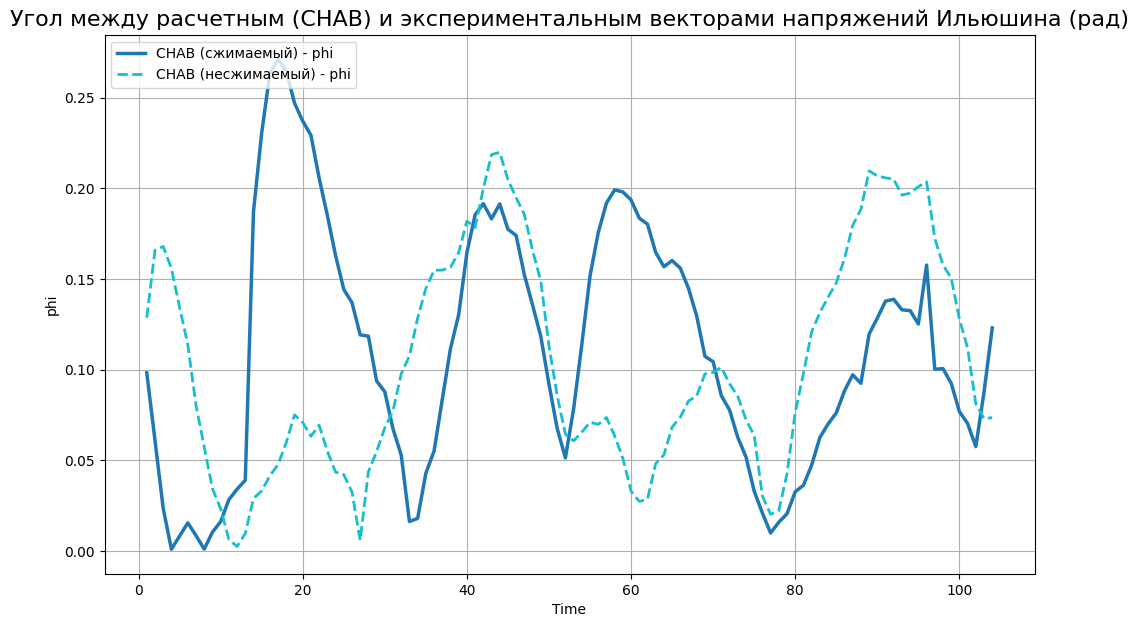

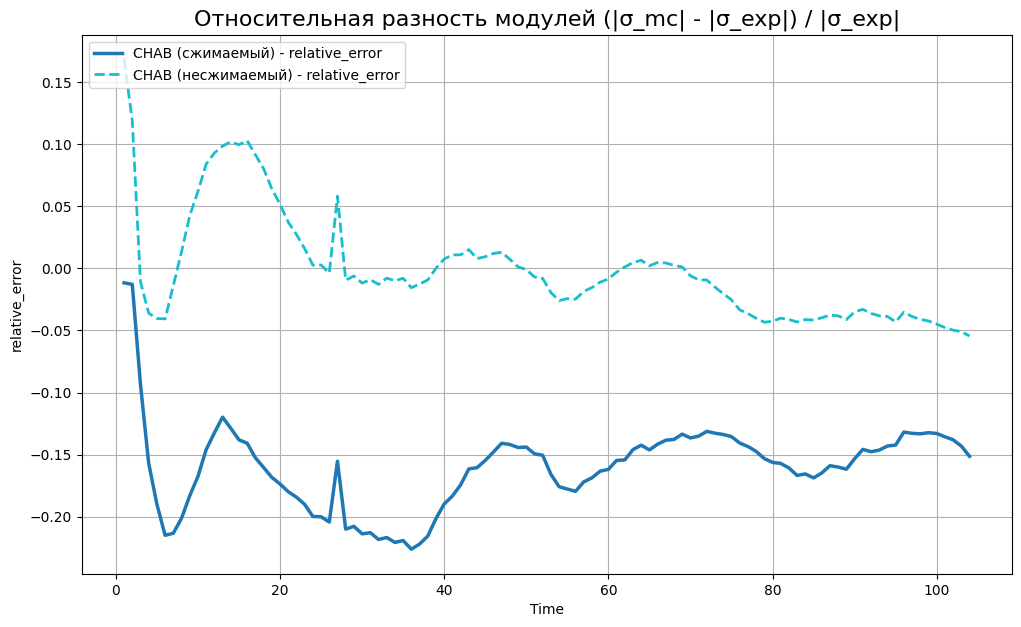

In [9]:
plot_xy(
    data_pairs=[
        (f"{model_name} (сжимаемый)", df_metrics),
        (f"{model_name} (несжимаемый)", df_metrics_inc),
    ],
    x_col="Time",
    y_cols=["phi"],
    title=f"Угол между расчетным ({model_name}) и экспериментальным векторами напряжений Ильюшина (рад)",
    figsize=(12, 7),
)

plot_xy(
    data_pairs=[
        (f"{model_name} (сжимаемый)", df_metrics),
        (f"{model_name} (несжимаемый)", df_metrics_inc),
    ],
    x_col="Time",
    y_cols=["relative_error"],
    title=f"Относительная разность модулей (|σ_mc| - |σ_exp|) / |σ_exp|",
    figsize=(12, 7),
)



#### Выводы по результатам сравнения (Ильюшин, см. графики выше)

1. **$\varepsilon_1^{Il}$ от $s$.** Фаза колебаний у расчёта (CHAB) и эксперимента согласована: экстремумы приходятся на близкие значения длины дуги $s$. По величине модель **систематически занижает** $\varepsilon_1^{Il}$; у опыта при $s=0$ заметен **ненулевой** уровень деформации при нуле в расчёте.

2. **$\varepsilon_2^{Il}$ от $s$.** Траектория близка к **линейному** росту с $s$; расчёт качественно повторяет опыт с **небольшим постоянным сдвигом вниз**. На расчётной кривой виден **излом наклона** в начале пути (около $s \approx 0{,}008$), после чего наклон стабилизируется.

3. **$\varepsilon_3^{Il}$ от $s$.** В первом цикле после выхода с нуля модель и опыт совпадают хорошо. На **втором и последующих** циклах нарастает **сдвиг по $s$**: экстремумы эксперимента смещены относительно расчётных (накопление фазового рассогласования вдоль дуги).

4. **$\sigma_1^{Il}$ от $s$.** В **первом** цикле амплитуды и форма близки. Далее расчётная кривая **опережает** эксперимент по фазе: пики и провалы модели достигаются при **меньших** $s$, чем у опыта.

5. **$\sigma_2^{Il}$ от $s$.** Общий тренд нагружения воспроизведён; у расчёта заметны **осцилляции**, тогда как экспериментальные точки образуют более **гладкую** кривую. К **концу** интервала по $s$ возможно расхождение (модель и опыт по-разному завершают участок пути).

6. **$\sigma_3^{Il}$ от $s$, угол $\varphi$ и относительная разность модулей.** По $\sigma_3^{Il}$ модель **недооценивает амплитуду**, особенно в **отрицательных** экстремумах; с ростом $s$ расхождение усиливается. Угол $\varphi$ между расчётным и экспериментальным векторами напряжений Ильюшина **непостоянен** вдоль $s$ (значимые пики порядка **~0,15–0,19 рад**). Относительная разность модулей $(|\boldsymbol{\sigma}^{\mathrm{числ}}|-|\boldsymbol{\sigma}^{\mathrm{эксп}}|)/|\boldsymbol{\sigma}^{\mathrm{эксп}}|$ меняется по траектории: есть **стартовые** провалы и пики, **узкий выброс** в отдельной точке $s$, интервал с ошибкой порядка нескольких процентов и **просадка** к концу пути (недооценка модуля расчётом).

Ниже — **второй этап** ($t > 14$): аппроксимация среднего напряжения (ось графика — время), кривизна и кручение по времени, затем уточнённый угол сближения на II этапе и **полный путь** для интенсивности и $\Theta$.


In [10]:
split_time_exp = 14.0

from core.calculations import calculate_mean_stress, ilushin_strain_path_length


def stage2_from_il(df_il, split_t, time_col="Time"):
    """II этап из кадра Ильюшина: те же Eps_*/Sig_*, плюс Sigma_Mean и дуга s с нуля по этапу."""
    out = df_il[df_il[time_col] > split_t].copy().reset_index(drop=True)
    calculate_mean_stress(out)
    s_stage = ilushin_strain_path_length(
        out, time_col=time_col, use_existing_ilushin_strains=True
    ).rename(columns={"s": "s_stage2"})
    if "s" in out.columns:
        out = out.drop(columns=["s"])
    out = out.merge(s_stage, on=time_col, how="inner")
    out["s"] = out["s_stage2"]
    return out


df_exp_stage2 = stage2_from_il(exp_il, split_time_exp)
numerical_experiment_stage2 = stage2_from_il(num_il, split_time_exp)
numerical_experiment_stage2_inc = stage2_from_il(num_il_inc, split_time_exp)

### Аппроксимация среднего напряжения (II этап, $t > 14$)

На втором этапе среднее напряжение $\sigma_{\mathrm{mean}} = (\sigma_{zz}+\sigma_{\theta\theta})/3$ (в данных — из $S_{ZZ}$, $S_{TT}$) аппроксимируется моделью **гармоника + линейный тренд**  как функция времени **вдоль второго этапа**:

$$\sigma_{\mathrm{mean}}(t) \approx p\cos(\omega t + \phi) + b_1 t + b_2.$$



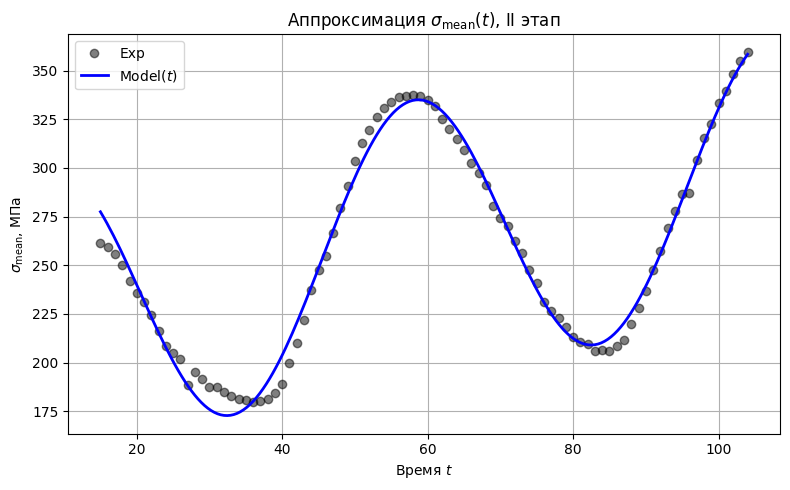

Параметры аппроксимации среднего напряжения (II этап, по времени):
  Амплитуда (p):            -71.8471 МПа
  Угловая частота (w):      0.1254 рад/ед. t
  Фаза (phi):               2.1418 рад
  Линейный тренд (b1):      0.7238 МПа/ед. t
  Базовое смещение (b2):    220.9126 МПа


In [11]:
from core.derivatives.stress_approximation import VolumetricModel
import matplotlib.pyplot as plt
import numpy as np


order = np.argsort(df_exp_stage2["Time"].to_numpy())
t_vals = df_exp_stage2["Time"].to_numpy()[order]
sig_vals = df_exp_stage2["Sigma_Mean"].to_numpy()[order]

vol_model_t = VolumetricModel()
t_span = float(t_vals.max() - t_vals.min())
w_guess = (4 * np.pi) / max(t_span, 1e-9)
params_t = vol_model_t.fit(t_vals, sig_vals, guess_w=w_guess)

plt.figure(figsize=(8, 5))
plt.plot(t_vals, sig_vals, "ko", alpha=0.5, label="Exp")
t_grid = np.linspace(t_vals.min(), t_vals.max(), 200)
plt.plot(t_grid, vol_model_t.predict(t_grid), "b-", lw=2, label=r"Model($t$)")
plt.title(r"Аппроксимация $\sigma_{\mathrm{mean}}(t)$, II этап")
plt.xlabel(r"Время $t$")
plt.ylabel(r"$\sigma_{\mathrm{mean}}$, МПа")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

p, w, phi, b1, b2 = params_t
print("Параметры аппроксимации среднего напряжения (II этап, по времени):")
print(f"  Амплитуда (p):            {p:.4f} МПа")
print(f"  Угловая частота (w):      {w:.4f} рад/ед. t")
print(f"  Фаза (phi):               {phi:.4f} рад")
print(f"  Линейный тренд (b1):      {b1:.4f} МПа/ед. t")
print(f"  Базовое смещение (b2):    {b2:.4f} МПа")

### Кривизна и кручение vs время $t$ (II этап)

Используется идеальная винтовая траектория в пространстве Ильюшина плюс поправка на объём (производные $\Delta$ по $t$ из аппроксимации **$\sigma_{\mathrm{mean}}(t)$**).

$$\varkappa = \frac{|\dot{\bar{\varepsilon}} \times \ddot{\bar{\varepsilon}}|}{|\dot{\bar{\varepsilon}}|^3}, \qquad
\tau = \frac{(\dot{\bar{\varepsilon}} \times \ddot{\bar{\varepsilon}}) \cdot \dddot{\bar{\varepsilon}}}{|\dot{\bar{\varepsilon}} \times \ddot{\bar{\varepsilon}}|^2}.$$


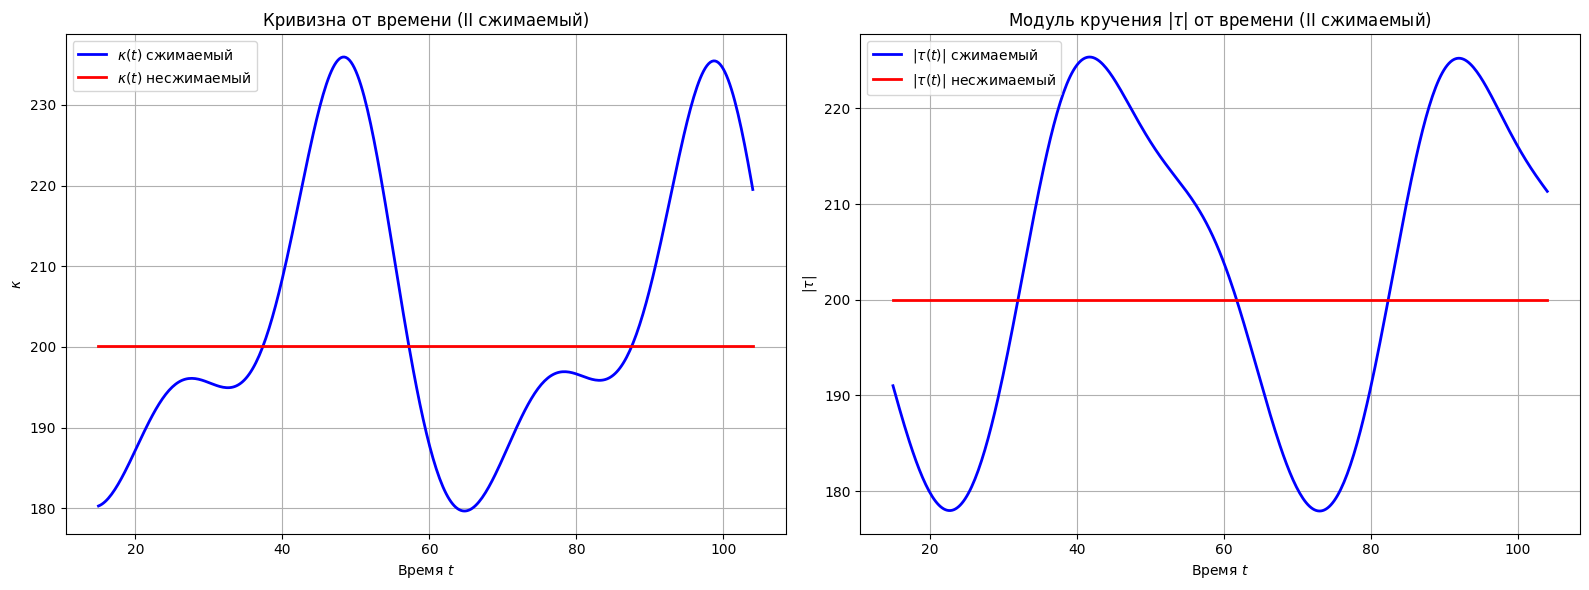

In [12]:
from core.derivatives.stress_approximation import GeometricProperties
from core.derivatives.analytical import AnalyticalDerivativesTime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


t_min = float(df_exp_stage2["Time"].min())
t_max = float(df_exp_stage2["Time"].max())
t_fine = np.linspace(t_min, t_max, 400)

row = num_il[num_il["Time"] > split_time_exp].sort_values("Time", kind="mergesort").iloc[0]
e1, e2 = float(row["Eps_1"]), float(row["Eps_2"])
eps_z_start = e1
eps_theta_start = (np.sqrt(3) * e2 - e1) / 2.0

adt = AnalyticalDerivativesTime(
    c=0.0025,
    a=0.0157,
    n_turns=1.75,
    time_array=t_fine,
    eps_z_start=eps_z_start,
    eps_theta_start=eps_theta_start,
)
d1, d2, d3 = adt.get_all_derivatives()
df_geom = pd.DataFrame(
    {
        "dEps_1_analytic": d1[0],
        "dEps_2_analytic": d1[1],
        "dEps_3_analytic": d1[2],
        "d2Eps_1_analytic": d2[0],
        "d2Eps_2_analytic": d2[1],
        "d2Eps_3_analytic": d2[2],
        "d3Eps_1_analytic": d3[0],
        "d3Eps_2_analytic": d3[1],
        "d3Eps_3_analytic": d3[2],
    }
)

geom = GeometricProperties(vol_model_t, E=2.05e5, nu=0.2999999999)
t_plot = adt.time
kappa, tau = geom.compute_geometry(df_geom, t_plot)

row = num_il_inc[num_il_inc["Time"] > split_time_exp].sort_values("Time", kind="mergesort").iloc[0]
e1_inc, e2_inc = float(row["Eps_1"]), float(row["Eps_2"])
eps_z_start_inc = e1_inc
eps_theta_start_inc = (np.sqrt(3) * e2_inc - e1_inc) / 2.0

adt_inc = AnalyticalDerivativesTime(
    c=0.0025,
    a=0.0157,
    n_turns=1.75,
    time_array=t_fine,
    eps_z_start=eps_z_start_inc,
    eps_theta_start=eps_theta_start_inc,
)
d1_inc, d2_inc, d3_inc = adt_inc.get_all_derivatives()
df_geom_inc = pd.DataFrame(
    {
        "dEps_1_analytic": d1_inc[0],
        "dEps_2_analytic": d1_inc[1],
        "dEps_3_analytic": d1_inc[2],
        "d2Eps_1_analytic": d2_inc[0],
        "d2Eps_2_analytic": d2_inc[1],
        "d2Eps_3_analytic": d2_inc[2],
        "d3Eps_1_analytic": d3_inc[0],
        "d3Eps_2_analytic": d3_inc[1],
        "d3Eps_3_analytic": d3_inc[2],
    }
)

geom_inc = GeometricProperties(vol_model_t, E=2.05e5, nu=0.4999999999)
t_plot = adt.time
kappa_inc, tau_inc = geom_inc.compute_geometry(df_geom_inc, t_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(t_plot, kappa, "b-", lw=2, label=r"$\kappa(t)$ сжимаемый")
ax1.plot(t_plot, kappa_inc, "r-", lw=2, label=r"$\kappa(t)$ несжимаемый")
ax1.set_title("Кривизна от времени (II сжимаемый)")
ax1.set_xlabel(r"Время $t$")
ax1.set_ylabel(r"$\kappa$")
ax1.grid(True)
ax1.legend()

ax2.plot(t_plot, np.abs(tau), "b-", lw=2, label=r"$|\tau(t)|$ сжимаемый ")
ax2.plot(t_plot, np.abs(tau_inc), "r-", lw=2, label=r"$|\tau(t)|$ несжимаемый")
ax2.set_title(r"Модуль кручения $|\tau|$ от времени (II сжимаемый)")
ax2.set_xlabel(r"Время $t$")
ax2.set_ylabel(r"$|\tau|$")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()

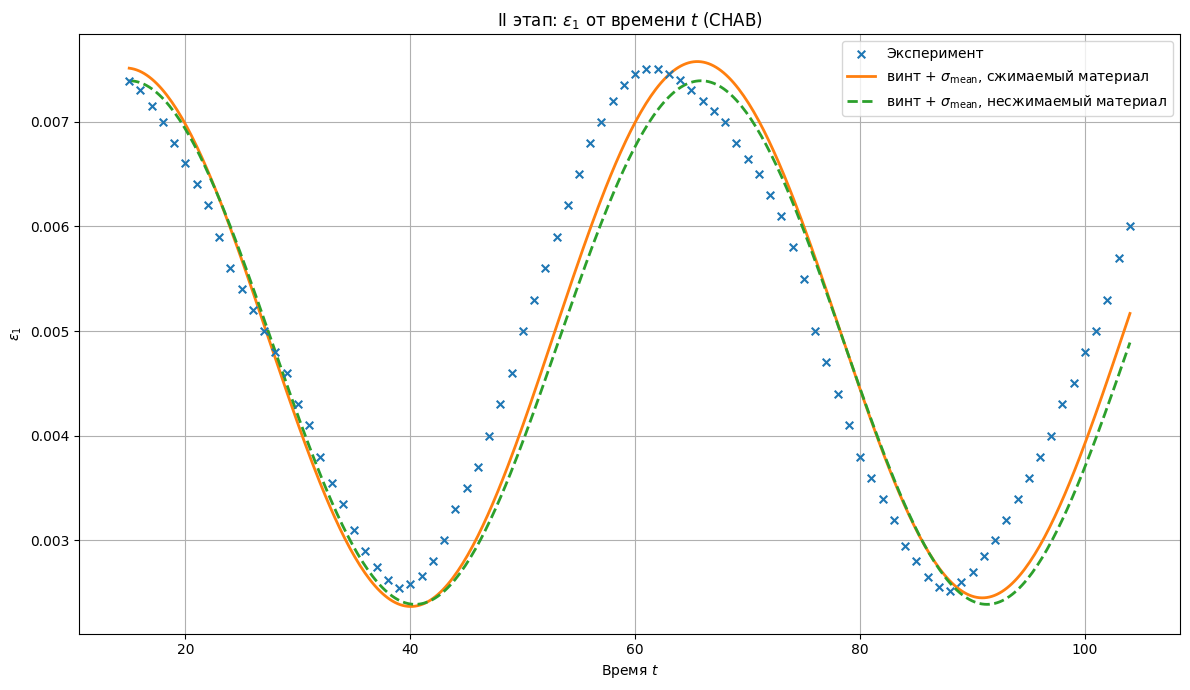

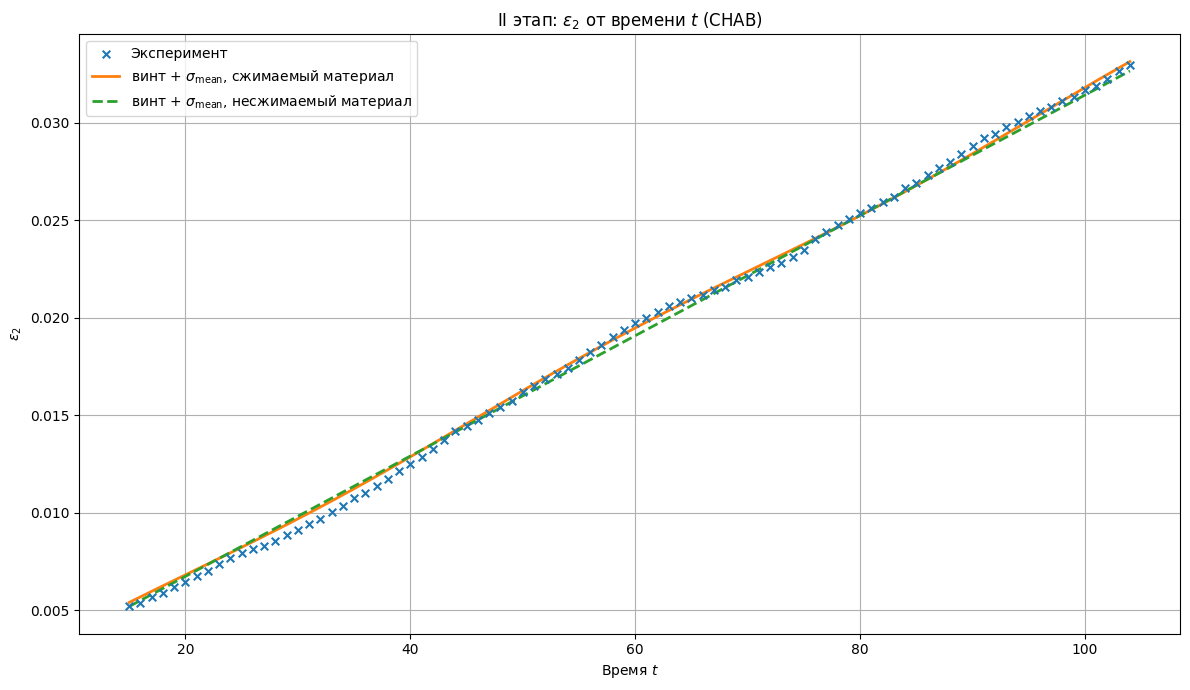

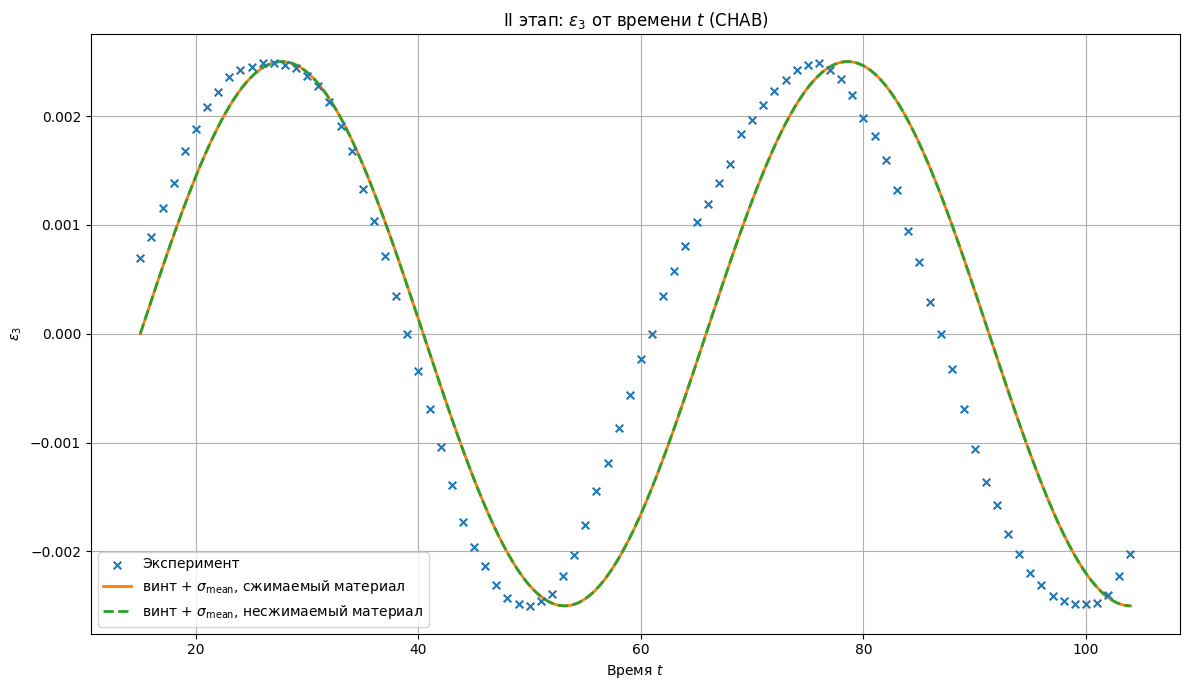

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- из предыдущей ячейки: adt, adt_inc, geom, geom_inc, t_plot ---

v1_a, v2_a, v3_a = adt.get_values()
df_eps_c = pd.DataFrame(
    {
        "Eps_1_analytic": v1_a,
        "Eps_2_analytic": v2_a,
        "Eps_3_analytic": v3_a,
    }
)
E1_c, E2_c, E3_c = geom.get_values(df_eps_c, t_plot)

v1_ai, v2_ai, v3_ai = adt_inc.get_values()
df_eps_i = pd.DataFrame(
    {
        "Eps_1_analytic": v1_ai,
        "Eps_2_analytic": v2_ai,
        "Eps_3_analytic": v3_ai,
    }
)
E1_i, E2_i, E3_i = geom_inc.get_values(df_eps_i, t_plot)

ex = df_exp_stage2.sort_values("Time", kind="mergesort")
t_ex = ex["Time"].to_numpy(dtype=float)

geom_curves = {1: (E1_c, E1_i), 2: (E2_c, E2_i), 3: (E3_c, E3_i)}

for k, title_tex in (
    (1, r"$\varepsilon_1$"),
    (2, r"$\varepsilon_2$"),
    (3, r"$\varepsilon_3$"),
):
    col = f"Eps_{k}"
    Ek_c, Ek_i = geom_curves[k]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.scatter(
        t_ex,
        ex[col].to_numpy(dtype=float),
        c="C0",
        marker="x",
        s=30,
        zorder=5,
        label="Эксперимент",
    )
    ax.plot(
        t_plot,
        Ek_c,
        "-",
        color="C1",
        lw=2,
        label=r"винт + $\sigma_{\mathrm{mean}}$, сжимаемый материал",
    )
    ax.plot(
        t_plot,
        Ek_i,
        "--",
        color="C2",
        lw=2,
        label=r"винт + $\sigma_{\mathrm{mean}}$, несжимаемый материал",
    )
    ax.set_title(f"II этап: {title_tex} от времени $t$ ({model_name})")
    ax.set_xlabel(r"Время $t$")
    ax.set_ylabel(title_tex)
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    plt.show()

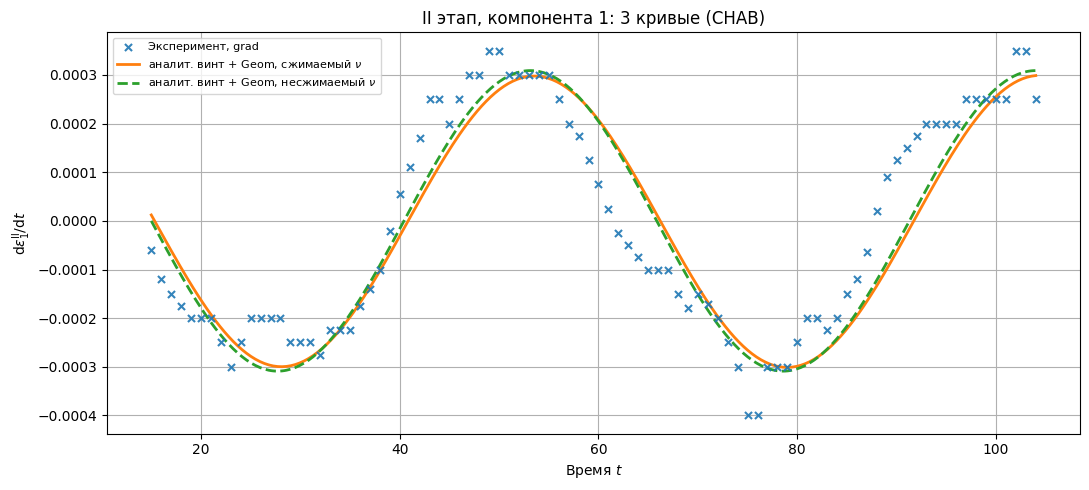

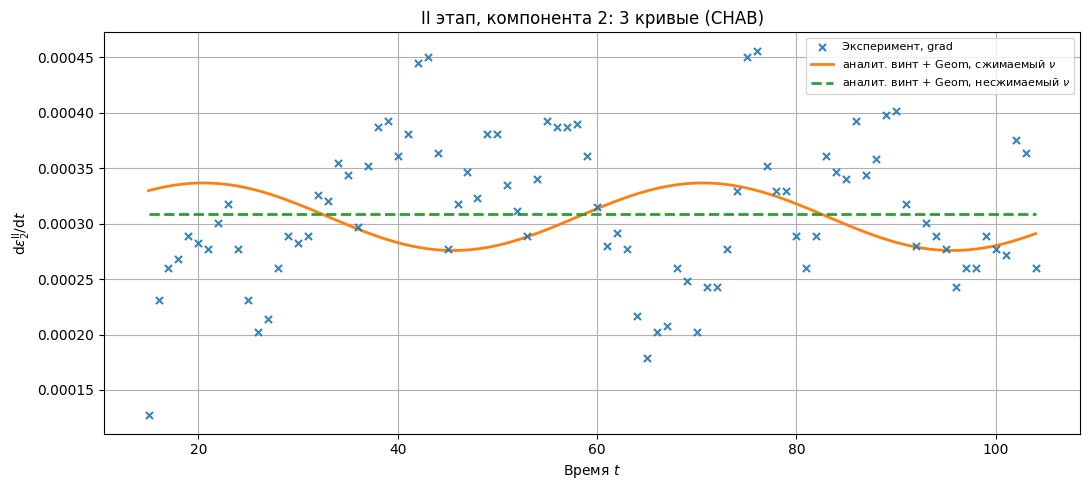

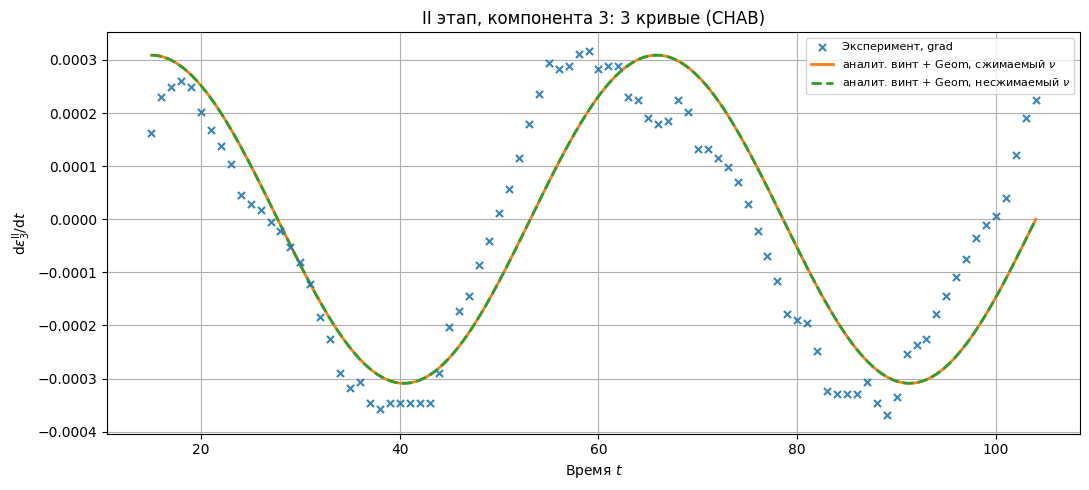

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def _t_and_deps_k(df: pd.DataFrame, k: int, time_col: str = "Time"):
    d = df.sort_values(time_col, kind="mergesort").reset_index(drop=True)
    t = d[time_col].to_numpy(dtype=float)
    gk = np.gradient(d[f"Eps_{k}"].to_numpy(dtype=float), t, edge_order=2)
    return t, gk


v_all = geom.get_derivatives(df_geom, t_plot)
v_all_i = geom_inc.get_derivatives(df_geom_inc, t_plot)

for k in (1, 2, 3):
    t_ex, g_ex = _t_and_deps_k(df_exp_stage2, k)
    vk = v_all[k - 1]
    vki = v_all_i[k - 1]

    plt.figure(figsize=(11, 5))
    plt.scatter(
        t_ex,
        g_ex,
        c="C0",
        marker="x",
        s=26,
        alpha=0.9,
        label="Эксперимент, grad",
        zorder=5,
    )
    plt.plot(
        t_plot,
        vk,
        "-",
        color="C1",
        lw=2,
        label=r"аналит. винт + Geom, сжимаемый $\nu$",
    )
    plt.plot(
        t_plot,
        vki,
        "--",
        color="C2",
        lw=2,
        label=r"аналит. винт + Geom, несжимаемый $\nu$",
    )
    plt.xlabel(r"Время $t$")
    plt.ylabel(rf"$\mathrm{{d}}\varepsilon_{{{k}}}^{{\mathrm{{Il}}}}/\mathrm{{d}}t$")
    plt.title(rf"II этап, компонента {k}: 3 кривые ({model_name})")
    plt.grid(True)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

### Интенсивность и угол сближения в пространстве Ильюшина

**Интенсивность напряжений** понимается как модуль вектора напряжений Ильюшина. Компоненты этого вектора получают из табличных данных: для эксперимента используются измеренные напряжения, для сравнения — напряжения из конечно-элементного расчёта (ANSYS) для выбранной модели материала.

**Угол сближения** — угол между вектором напряжений и вектором скорости изменения деформаций вдоль траектории в пространстве Ильюшина (арккосинус от нормированного скалярного произведения).

**Эксперимент (Theta Experiment):** скорость деформаций задаётся **только по данным опыта**: компоненты $\varepsilon^{\mathrm{Il}}$ из измеренных полных деформаций, производные по глобальной дуге $s$ — **`np.gradient` вдоль $s$** (аналогично `analysis.ipynb`). Аппроксимация $\sigma_{\mathrm{mean}}(s)$ для касательной **не используется**.

**ANSYS, зелёная кривая:** на **I этапе** ($t \le 14$) касательная — **`np.gradient`** по численным $\varepsilon^{\mathrm{Il}}$ вдоль глобальной $s$; на **II этапе** — гладкая касательная из **аппроксимации** $\sigma_{\mathrm{mean}}(s)$ только по II этапу + винтовая кинематика (`GeometricProperties`), т.к. вид функции на I этапе заранее не фиксируется.

**ANSYS, пунктир:** производные по $s$ **конечными разностями** между соседними точками вдоль накопленной дуги (диагностика чувствительности к дискретизации).

**Два расчёта ANSYS:** сжимаемый и несжимаемый (`chab.csv`, `chab_incompressible.csv`). На графике угла: **зелёная** — гибрид «Theta ANSYS: I этап — конечные разности; II — σ_mean(s)+винт» только для **сжимаемого** CHAB; **пурпурная** и **оливковая** (`-.`) — конечные разности $d\varepsilon/ds$ по $s$ для сжимаемого и несжимаемого расчёта; **точки** — опыт (`np.gradient`).


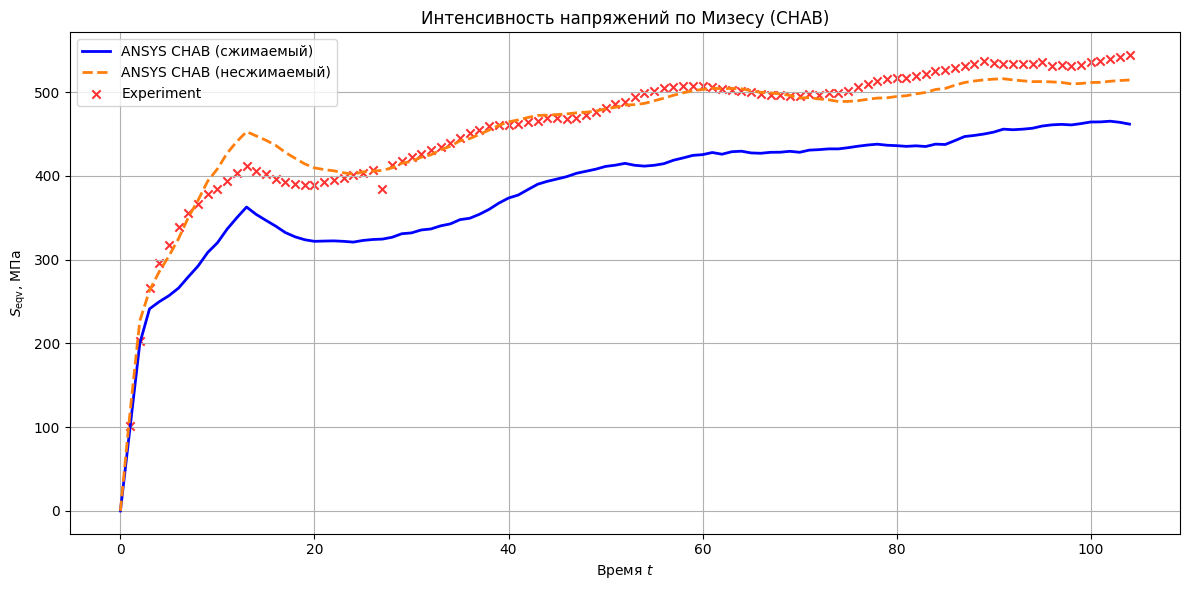

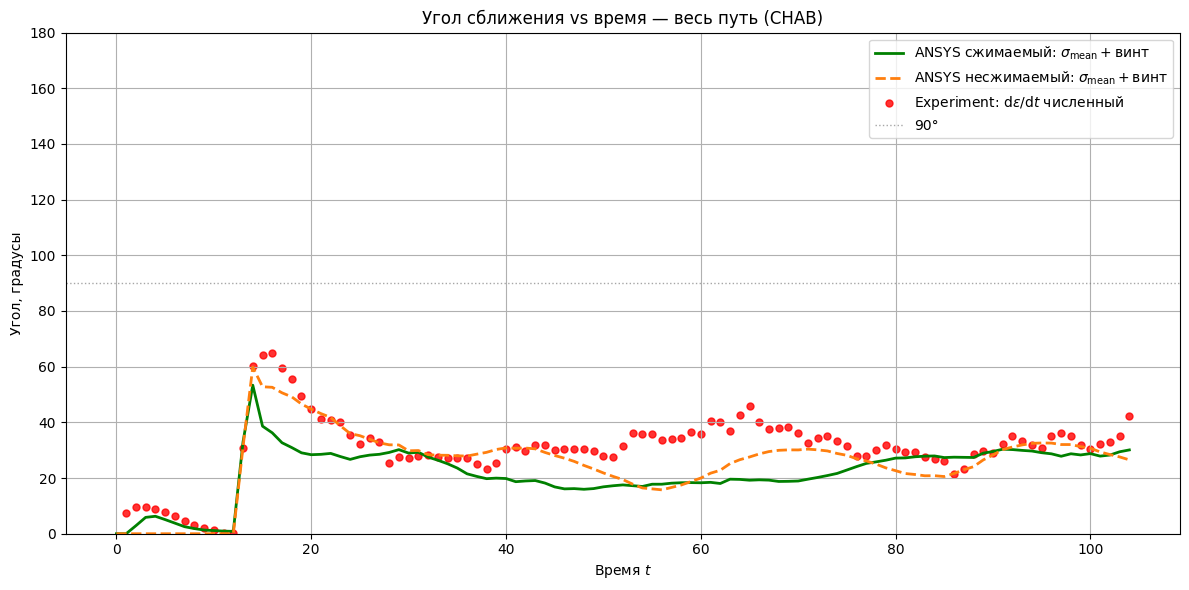

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from core.calculations import (
    calculate_mean_stress,
    calculate_theta,
    calculate_von_mises_stress,
)
from core.derivatives.analytical import AnalyticalDerivativesTime
from core.derivatives.stress_approximation import GeometricProperties, VolumetricModel

C_HELIX, A_HELIX, N_TURNS = 0.0025, 0.0157, 1.65


def _eps_starts_from_num_il(num_il_df: pd.DataFrame, split_t: float) -> tuple[float, float]:
    row = num_il_df[num_il_df["Time"] > split_t].sort_values("Time", kind="mergesort").iloc[0]
    e1, e2 = float(row["Eps_1"]), float(row["Eps_2"])
    return e1, (np.sqrt(3) * e2 - e1) / 2.0


def _blend_theta_branch(
    num_il_df: pd.DataFrame,
    num_stage2: pd.DataFrame,
    split_t: float,
    *,
    nu_mat: float,
) -> pd.DataFrame:
    nc = num_il_df.sort_values("Time", kind="mergesort").reset_index(drop=True).copy()
    nc = nc.rename(columns={"s": "s_il"})
    calculate_mean_stress(nc)
    nc = nc.merge(num_stage2[["Time", "s_stage2"]], on="Time", how="left")

    t_arr = nc["Time"].to_numpy(dtype=float)
    E_num = nc[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
    d_num_grad = np.gradient(E_num, t_arr, axis=0, edge_order=2)

    num2 = num_stage2.copy()
    calculate_mean_stress(num2)
    vm_n = VolumetricModel()
    vm_n.fit(num2["Time"].to_numpy(dtype=float), num2["Sigma_Mean"].to_numpy(dtype=float))

    eps_z0, eps_th0 = _eps_starts_from_num_il(num_il_df, split_t)
    mask2 = (nc["Time"] > split_t).to_numpy()
    vn_blend = d_num_grad.copy()
    if np.any(mask2):
        t2 = nc.loc[mask2, "Time"].to_numpy(dtype=float)
        if t2.size < 2:
            raise ValueError("На II этапе нужно ≥ 2 точек по времени для AnalyticalDerivativesTime.")
        adt = AnalyticalDerivativesTime(
            c=C_HELIX,
            a=A_HELIX,
            n_turns=N_TURNS,
            time_array=t2,
            eps_z_start=eps_z0,
            eps_theta_start=eps_th0,
        )
        d1, d2, d3 = adt.get_all_derivatives()
        df_geom = pd.DataFrame(
            {
                "dEps_1_analytic": d1[0],
                "dEps_2_analytic": d1[1],
                "dEps_3_analytic": d1[2],
                "d2Eps_1_analytic": d2[0],
                "d2Eps_2_analytic": d2[1],
                "d2Eps_3_analytic": d2[2],
                "d3Eps_1_analytic": d3[0],
                "d3Eps_2_analytic": d3[1],
                "d3Eps_3_analytic": d3[2],
            }
        )
        ap_n = GeometricProperties(vm_n, E=2.05e5, nu=nu_mat)
        v1, v2, v3 = ap_n.get_derivatives(df_geom, t2)
        vn_blend[mask2, 0] = v1
        vn_blend[mask2, 1] = v2
        vn_blend[mask2, 2] = v3

    df_tn = pd.DataFrame(
        {
            "Sig_1": nc["Sig_1"].to_numpy(),
            "Sig_2": nc["Sig_2"].to_numpy(),
            "Sig_3": nc["Sig_3"].to_numpy(),
            "dEps_1_approx": vn_blend[:, 0],
            "dEps_2_approx": vn_blend[:, 1],
            "dEps_3_approx": vn_blend[:, 2],
        }
    )
    nc["Theta"] = calculate_theta(df_tn, deriv_suffix="_approx")
    calculate_von_mises_stress(nc)
    return nc


re_s = exp_il.sort_values("Time", kind="mergesort").reset_index(drop=True).copy()
calculate_mean_stress(re_s)
E_re = re_s[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
t_re = re_s["Time"].to_numpy(dtype=float)
d_re = np.gradient(E_re, t_re, axis=0, edge_order=2)
df_te = pd.DataFrame(
    {
        "Sig_1": re_s["Sig_1"].to_numpy(),
        "Sig_2": re_s["Sig_2"].to_numpy(),
        "Sig_3": re_s["Sig_3"].to_numpy(),
        "dEps_1_grad": d_re[:, 0],
        "dEps_2_grad": d_re[:, 1],
        "dEps_3_grad": d_re[:, 2],
    }
)
re_s["Theta"] = calculate_theta(df_te, deriv_suffix="_grad")
calculate_von_mises_stress(re_s)


nc_s = _blend_theta_branch(num_il, numerical_experiment_stage2, split_time_exp, nu_mat=0.29999999)
nc_s_inc = _blend_theta_branch(num_il_inc, numerical_experiment_stage2_inc, split_time_exp, nu_mat=0.49999999)


plt.figure(figsize=(12, 6))
plt.plot(nc_s["Time"], nc_s["S_EQV"], "b-", lw=2, label=f"ANSYS {model_name} (сжимаемый)")
plt.plot(nc_s_inc["Time"], nc_s_inc["S_EQV"], color="C1", ls="--", lw=2, label=f"ANSYS {model_name} (несжимаемый)")
plt.scatter(re_s["Time"], re_s["S_EQV"], c="r", marker="x", label="Experiment", alpha=0.8)
plt.title(f"Интенсивность напряжений по Мизесу ({model_name})")
plt.xlabel("Время $t$")
plt.ylabel(r"$S_{\mathrm{eqv}}$, МПа")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(
    nc_s["Time"],
    nc_s["Theta"],
    "g-",
    lw=2,
    label=r"ANSYS сжимаемый: $\sigma_{\mathrm{mean}}+\mathrm{винт}$",
)
plt.plot(
    nc_s_inc["Time"],
    nc_s_inc["Theta"],
    color="C1",
    ls="--",
    lw=2,
    label=r"ANSYS несжимаемый: $\sigma_{\mathrm{mean}}+\mathrm{винт}$",
)
plt.scatter(
    re_s["Time"],
    re_s["Theta"],
    c="r",
    marker="o",
    s=25,
    label=r"Experiment: $\mathrm{d}\varepsilon/\mathrm{d}t$ численный",
    alpha=0.8,
)
plt.title(f"Угол сближения vs время — весь путь ({model_name})")
plt.xlabel("Время $t$")
plt.ylabel("Угол, градусы")
plt.axhline(90, color="gray", ls=":", lw=1, alpha=0.7, label="90°")
plt.legend()
plt.grid(True)
plt.ylim(0, 180)
plt.tight_layout()
plt.show()

### Выводы: интенсивность $|\Sigma|$ и угол сближения $\Theta$ на всём пути (CHAB)

**Интенсивность $|\Sigma|(s)$.** В начале пути расчёт и опыт расходятся по уровню (в т.ч. старт с нуля у ANSYS при ненулевой интенсивности в эксперименте — следствие разных начальных/пограничных условий и представления данных). Далее кривые качественно согласованы, но у ANSYS заметна **волнообразность**, тогда как опыт ближе к **монотонному** росту с шумом; к концу дуги $s$ интенсивность эксперимента может **превосходить** расчёт. Это согласуется с рассогласованием модулей напряжений Ильюшина по траектории (см. график относительной ошибки выше).

**Угол сближения $\Theta(s)$.** На графике виден **резкий переход** около $s \approx 0{,}007$: до него угол у расчётных кривых ANSYS (и частично у опыта) **близок к нулю**, после — **скачкообразный рост** к величинам порядка $60^\circ$ и дальше колебательный ход. Такой излом согласуется со **сшивкой постановок** на границе этапов: на I этапе касательная к траектории в пространстве Ильюшина задаётся **численно** (`np.gradient` по данным CHAB), на II этапе для **зелёной** линии подключается **модельная** касательная (аппроксимация $\sigma_{\mathrm{mean}}(s)$ по II этапу + винтовая кинематика). В точке сшивки направление «скорости» деформаций меняется с **оценки по фактической дискретной траектории** на **заданную аналитически** — это неизбежно даёт **производный** скачок на кривой $\Theta$, если модельная касательная не совпадает с градиентом по тем же точкам.

**Эксперимент** на графике строится **только из данных опыта**: $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$ — **`np.gradient`** вдоль глобальной дуги $s$. На **второй фазе** пути ($s$ после указанного излома) точки опыта по **уровню и фазе колебаний** заметно **ближе к пурпурной линии** (конечные разности по шагам ANSYS вдоль той же дуги), чем к **зелёной**. Иначе говоря, **дискретная** касательная к траектории деформаций из FE **лучше согласуется** с касательной, восстановленной по эксперименту, чем **гладкая** касательная из схемы «$\sigma_{\mathrm{mean}}(s)$ + винт». Зелёная кривая на длинном участке II этапа **систематически завышает** $\Theta$ относительно опыта (пики около $60^\circ$ у зелёной при том, что у опыта и пунктира максимумы чаще укладываются примерно в $30^\circ$–$40^\circ$). Это указывает на то, что **аналитическая постановка касательной на II этапе** не полностью отражает **фактическое** направление $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$ ни в расчёте (сравнение зелёной и пурпурной), ни в эксперименте.

**Почему пурпурная линия в начале пути низкая, а после скачка ближе к опыту?** (1) На **малых** $s$ конечная разность по **первым** шагам даёт направление **почти сонаправленное** с $\boldsymbol{\sigma}^{\mathrm{Il}}$ (малый угол между векторами), тогда как после накопления дуги направление приращения **отклоняется** — угол растёт. (2) **Пурпурная** и **зелёная** ветви ANSYS на II этапе используют **разные** определения $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$ (ломаная vs модельный винт); расхождение между ними — мера **неадекватности замены** реальной касательной гладкой моделью. (3) Шум и погрешности **экспериментальных** $\varepsilon^{\mathrm{Il}}$ при `np.gradient` дают разброс точек; тем не менее **средний тренд** опыта на II этапе последовательнее поддерживает **пурпурную** ветвь, а не зелёную.

**Итог по углу:** для **сопоставления с опытом** на II этапе разумнее ориентироваться на **касательную, восстановленную по данным** (у опыта — `np.gradient`; у ANSYS — как минимум сопоставлять с **конечными разностями** по той же дискретной траектории). **Зелёная** линия полезна как **модельный** вариант с явной аппроксимацией $\sigma_{\mathrm{mean}}$ и винтом, но она **не дублирует** ни дискретную кинематику FE, ни экспериментальную оценку $\Theta$ на колебательном участке.

